###1: MOUNT DRIVE & INSTALL DEPENDENCIES

In [1]:
# CELL 1: SYSTEM INITIALIZATION
from google.colab import drive
import os

print(" Initializing S.E.N.T.I.N.E.L. Environment...")

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Install Ultralytics (YOLO)
!pip install ultralytics -q

print(" Drive Mounted & Libraries Installed.")

 Initializing S.E.N.T.I.N.E.L. Environment...
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00
 Drive Mounted & Libraries Installed.


In [2]:
from ultralytics import YOLO
import os

# 1. Define the path (Based on our previous setup)
# If this fails, try: '/content/runs/detect/train/weights/best.pt'
model_path = '/content/drive/MyDrive/Military_iitbhu/Sentinel_Finals/best.pt'

print(f"🔍 Checking model at: {model_path}...")

if os.path.exists(model_path):
    print("✅ File exists! Attempting to load...")

    try:
        # 2. Load the model
        model = YOLO(model_path)

        # 3. Print the internal "Blueprints" (Architecture)
        print("\n--- ARCHITECTURE CHECK ---")
        # If this prints a table of layers, the architecture is INSIDE the file.
        model.info()

        # 4. Print the Class Names (e.g., Tank, Soldier)
        print("\n--- CLASS NAMES ---")
        print(model.names)

        print("\n🎉 VERDICT: SAFE. This model is standalone. You do NOT need model.py.")

    except Exception as e:
        print(f"\n❌ ERROR: The model failed to load. Reason: {e}")
else:
    print("❌ File not found. Please check if you moved it to 'Sentinel_Finals' or if it is still in 'runs/detect/train/weights/'.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 Checking model at: /content/drive/MyDrive/Military_iitbhu/Sentinel_Finals/best.pt...
✅ File exists! Attempting to load...

--- ARCHITECTURE CHECK ---
Model summary: 169 layers, 25,861,531 parameters, 0 gradients, 79.1 GFLOPs

--- CLASS NAMES ---
{0: 'camouflage_soldier', 1: 'weapon', 2: 'military_tank', 3: 'military_truck', 4: 'military_vehicle', 5: 'soldier', 6: 'military_artillery', 7: 'military_aircraft', 8: 'military_warship'}

🎉 VERDICT: SAFE. This model is standalone. You do NOT need model.py.


###2: DATASET EXTRACTION

In [2]:
# CELL 2: DATASET EXTRACTION
import zipfile
import glob

# CONFIGURATION
ZIP_PATH = '/content/drive/MyDrive/Military_iitbhu/Data/military_object_dataset.zip'
EXTRACT_PATH = '/content/dataset'

# LOGIC
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f" Critical Error: Dataset ZIP not found at {ZIP_PATH}")

if not os.path.exists(os.path.join(EXTRACT_PATH, 'military_object_dataset')):
    print(f" Extracting dataset to: {EXTRACT_PATH}")
    os.makedirs(EXTRACT_PATH, exist_ok=True)

    print(" Unzipping... (This takes ~30 seconds)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(" Unzip Complete.")
else:
    print(" Dataset already extracted. Skipping.")

# VERIFY
img_count = len(glob.glob(f'{EXTRACT_PATH}/**/*.jpg', recursive=True))
print(f" Verified {img_count} images available for analysis.")

 Extracting dataset to: /content/dataset
 Unzipping... (This takes ~30 seconds)
 Unzip Complete.
 Verified 14337 images available for analysis.


###3: CONFIGURATION & IMPORTS

In [3]:
# CELL 3: CONFIGURATION & IMPORTS
import cv2
import numpy as np
import random
import time
from ultralytics import YOLO
from tqdm import tqdm
from google.colab.patches import cv2_imshow

# PATHS
BASE_DIR = '/content/drive/MyDrive/Military_iitbhu/Sentinel_Finals'
MODEL_PATH = os.path.join(BASE_DIR, 'best.pt')
OUTPUT_DIR = os.path.join(BASE_DIR, 'Output_Product/Final_Tactical_HUD')
DATASET_ROOT = '/content/dataset/military_object_dataset'

# Create Output Directory
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f" Configuration Loaded.")
print(f" Output will be saved to: {OUTPUT_DIR}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Configuration Loaded.
 Output will be saved to: /content/drive/MyDrive/Military_iitbhu/Sentinel_Finals/Output_Product/Final_Tactical_HUD


###4: THE BRAIN (LOGIC & MATH)

In [4]:
# CELL 4: TACTICAL LOGIC ENGINE

# 1. REVERSE MAPPING (Model ID -> Real ID)
# ----------------------------------------
REVERSE_MAP = {
    0: 0, 1: 1, 2: 2, 3: 3, 4: 4,
    5: 6, # FIX: Model 5 is Real Soldier
    6: 8, # FIX: Model 6 is Real Artillery
    7: 10, 8: 11
}

LABELS = {
    0:'CAMO', 1:'WEAPON', 2:'TANK', 3:'TRUCK', 4:'VEHICLE',
    5:'CIVILIAN', 6:'SOLDIER', 8:'ARTILLERY', 10:'AIRCRAFT', 11:'WARSHIP'
}

# 2. THREAT GRAVITY WEIGHTS
# ----------------------------------------
# Used to calculate the "High Impact" Coordinate
THREAT_WEIGHTS = {
    2: 10.0, # Tank (Heavy)
    8: 9.0,  # Artillery
    10: 8.0, # Aircraft
    3: 6.0,  # Truck
    1: 5.0,  # Weapon
    0: 2.0,  # Soldier
    6: 2.0,  # Soldier
    5: 0.0   # Civilian (Ignored)
}

# 3. MATH FUNCTIONS
# ----------------------------------------
def calculate_high_impact_point(detections):
    """
    Calculates the 'Center of Gravity' of the threat cluster.
    Heavier threats pull the center closer to them.
    """
    total_weight = 0
    wx = 0
    wy = 0

    for det in detections:
        cls = det['class']
        weight = THREAT_WEIGHTS.get(cls, 0)

        if weight > 0:
            cx, cy = det['center']
            wx += cx * weight
            wy += cy * weight
            total_weight += weight

    if total_weight > 0:
        return (int(wx / total_weight), int(wy / total_weight))
    return None

def get_grid_ref(x, y, w, h):
    """Generates a pseudo-MGRS Military Grid Reference."""
    # Simulates: Grid Zone 34S, Square WC, Easting, Northing
    e = int((x / w) * 10000)
    n = int((y / h) * 10000)
    return f"34S WC {e:04d} {n:04d}"

print(" Tactical Logic Engine: ONLINE")

 Tactical Logic Engine: ONLINE


###5: THE VISUALIZER (SCI-FI HUD)

In [5]:
# CELL 5: SCI-FI HUD RENDERER

def draw_bracket(img, x, y, w, h, color, label, tid):
    """Draws tactical corner brackets with ID tag."""
    l = int(min(w, h) / 4) # Bracket arm length
    t = 2 # Thickness

    # Draw 4 Corners
    # Top-Left
    cv2.line(img, (x, y), (x + l, y), color, t)
    cv2.line(img, (x, y), (x, y + l), color, t)
    # Top-Right
    cv2.line(img, (x + w, y), (x + w - l, y), color, t)
    cv2.line(img, (x + w, y), (x + w, y + l), color, t)
    # Bottom-Left
    cv2.line(img, (x, y + h), (x + l, y + h), color, t)
    cv2.line(img, (x, y + h), (x, y + h - l), color, t)
    # Bottom-Right
    cv2.line(img, (x + w, y + h), (x + w - l, y + h), color, t)
    cv2.line(img, (x + w, y + h), (x + w, y + h - l), color, t)

    # ID Tag (Glass effect)
    overlay = img.copy()
    cv2.rectangle(overlay, (x, y-25), (x+120, y-2), color, -1)
    cv2.addWeighted(overlay, 0.6, img, 0.4, 0, img)

    cv2.putText(img, f"T-{tid:02d} | {label}", (x+5, y-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)

def draw_impact_reticle(img, x, y):
    """Draws the High Impact Target (Orange)."""
    c = (0, 140, 255)
    # Crosshair
    cv2.line(img, (x-30, y), (x+30, y), c, 1)
    cv2.line(img, (x, y-30), (x, y+30), c, 1)
    # Rings
    cv2.circle(img, (x, y), 20, c, 1)
    cv2.circle(img, (x, y), 5, c, -1)
    # Text
    cv2.putText(img, "PRIMARY IMPACT", (x+25, y-25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, c, 1)

def draw_sidebar(img, detections, impact_point):
    """Draws the right-side Target Manifest."""
    h, w = img.shape[:2]
    side_w = 320

    # Background Panel
    overlay = img.copy()
    cv2.rectangle(overlay, (w-side_w, 0), (w, h), (5, 5, 5), -1)
    cv2.addWeighted(overlay, 0.85, img, 0.15, 0, img)

    # Header
    cv2.putText(img, "TARGET MANIFEST", (w-side_w+15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    cv2.line(img, (w-side_w+15, 40), (w-15, 40), (0, 255, 0), 1)

    # Target List
    y = 70
    for i, det in enumerate(detections):
        tid = i + 1
        label = LABELS.get(det['class'], 'UNK')
        grid = det['grid']

        # Color coding
        c = (200, 200, 200) # White text
        if label == 'TANK': c = (0, 0, 255) # Red text for tanks

        cv2.putText(img, f"[{tid:02d}] {label}", (w-side_w+15, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1)
        cv2.putText(img, f"     {grid}", (w-side_w+15, y+20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 200, 255), 1)
        y += 45

    # Impact Coord Section
    if impact_point:
        y += 20
        cv2.line(img, (w-side_w+15, y), (w-15, y), (0, 140, 255), 1)
        y += 25
        cv2.putText(img, "OPTIMAL STRIKE COORD", (w-side_w+15, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 140, 255), 2)
        y += 25
        grid = get_grid_ref(impact_point[0], impact_point[1], w, h)
        cv2.putText(img, f"GRID: {grid}", (w-side_w+15, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1)

print(" Sci-Fi HUD Renderer: READY")

 Sci-Fi HUD Renderer: READY


###6: EXECUTION (MAIN LOOP)

 Loading Champion Model...
 Analyzing 20 Targets...


  0%|          | 0/20 [00:00<?, ?it/s]


--- Output: HUD_Tactical_00.jpg ---


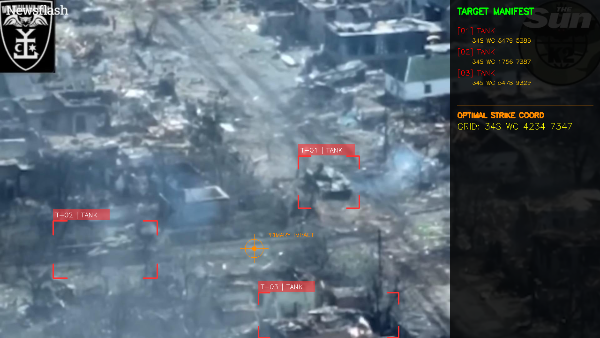

  5%|▌         | 1/20 [00:03<01:00,  3.16s/it]


--- Output: HUD_Tactical_01.jpg ---


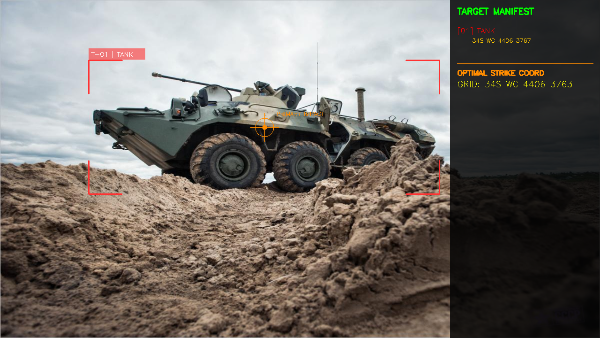

 10%|█         | 2/20 [00:05<00:50,  2.79s/it]


--- Output: HUD_Tactical_02.jpg ---


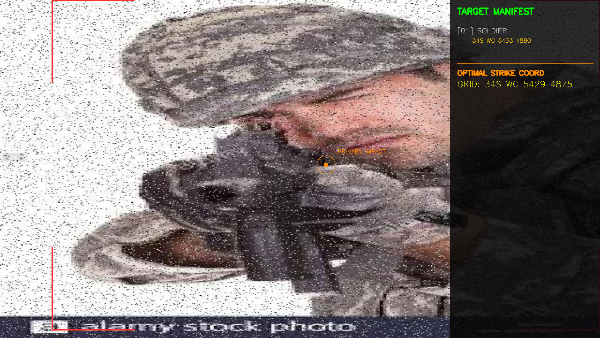

100%|██████████| 20/20 [00:45<00:00,  2.30s/it]


 COMPLETE. Images saved to: /content/drive/MyDrive/Military_iitbhu/Sentinel_Finals/Output_Product/Final_Tactical_HUD


In [6]:
# CELL 6: MAIN EXECUTION

print(" Loading Champion Model...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f" Model not found at {MODEL_PATH}")

model = YOLO(MODEL_PATH)

# Find Images (Prefer Validation Set)
search_path = os.path.join(DATASET_ROOT, '**/val/images/*.jpg')
images = glob.glob(search_path, recursive=True)
if not images:
    images = glob.glob(os.path.join(DATASET_ROOT, '**/*.jpg'), recursive=True)

# Pick 20 Samples
test_batch = random.sample(images, 20) if len(images) > 20 else images

print(f" Analyzing {len(test_batch)} Targets...")

for i, img_path in enumerate(tqdm(test_batch)):
    img = cv2.imread(img_path)
    if img is None: continue

    # 1. Resize for HD HUD
    img = cv2.resize(img, (1280, 720))
    h, w = img.shape[:2]

    # 2. Predict
    results = model(img, verbose=False, conf=0.25)

    # 3. Extract Data
    detections = []
    for r in results:
        for box in r.boxes:
            m_cls = int(box.cls[0])
            r_cls = REVERSE_MAP.get(m_cls, m_cls) # Apply Fix
            x, y, x2, y2 = box.xywh[0].tolist() # Center x,y, w, h

            # Draw coords (Top-Left, Bottom-Right)
            x1 = int(x - x2/2)
            y1 = int(y - y2/2)

            detections.append({
                'class': r_cls,
                'center': (int(x), int(y)),
                'box': (x1, y1, int(x2), int(y2)),
                'grid': get_grid_ref(x, y, w, h)
            })

    # 4. Math: Calculate Impact Point
    impact_point = calculate_high_impact_point(detections)

    # 5. Render HUD
    # Draw individual targets
    for idx, det in enumerate(detections):
        x1, y1, bw, bh = det['box']
        label = LABELS.get(det['class'], 'UNK')

        # Colors
        color = (50, 50, 255) # Red for military
        if label == 'CIVILIAN': color = (0, 215, 255) # Yellow/Cyan

        draw_bracket(img, x1, y1, bw, bh, color, label, idx+1)

    # Draw High Impact
    if impact_point:
        draw_impact_reticle(img, impact_point[0], impact_point[1])

    # Draw Sidebar
    draw_sidebar(img, detections, impact_point)

    # 6. Save & Display
    filename = f"HUD_Tactical_{i:02d}.jpg"
    save_path = os.path.join(OUTPUT_DIR, filename)
    cv2.imwrite(save_path, img)

    if i < 3:
        print(f"\n--- Output: {filename} ---")
        cv2_imshow(cv2.resize(img, (600, 338)))

print(f"\n COMPLETE. Images saved to: {OUTPUT_DIR}")